# ⚖️ Binary Classification – ERD/ERS Dataset (Robust Preprocessing v2)
**Task:** Classify between **any 2 of the 9 EEG scenarios** (user-selectable)  
**Output folder:** `binary_erd_ers_dataset_outputs/`

> Uses `erd_ers_band_power.csv`. Pivoted to wide format, then group-aware split.

### What Changed & Why

| # | Fix | Root cause addressed |
|---|-----|----------------------|
| 1 | **Z-score on ALL 9 scenarios before filtering** | Original z-scored only on the 2 selected scenarios — each subject had only 18 rows, giving unstable statistics. Now z-score uses all 81 rows per subject. |
| 2 | **Engineered features: laterality, midline, cross-band ratios** | Only 27 raw features exist. Adding C4−C3 asymmetry, Cz midline dominance, and Low_Beta/Mu ratios brings discriminative signal invisible in raw features. |
| 3 | **ALS/Normal category flag** | Subject category is a real covariate. It is balanced across both classes (each subject has both scenarios), so it does not leak the label but may help separate subject clusters. |
| 4 | **Honest performance warning** | Some scenario pairs (e.g. S1 vs S2 = left hand vs right hand) are neurologically near-indistinguishable from 3 channels of band power alone. The notebook now prints an interpretability note alongside results. |

### 9 Available Scenarios
| # | Scenario |
|---|----------|
| 1 | Lifting the left hand |
| 2 | Lifting the right hand |
| 3 | Lifting the left leg |
| 4 | Lifting the right leg |
| 5 | Opening the mouth |
| 6 | Nodding the head |
| 7 | Shaking head |
| 8 | Desiring to drink water |
| 9 | Desiring to use the bathroom |


## 0. Setup

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (cross_val_score, GroupShuffleSplit, GroupKFold)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              RocCurveDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

SCENARIO_LABELS = {
    1: 'Lifting the left hand',
    2: 'Lifting the right hand',
    3: 'Lifting the left leg',
    4: 'Lifting the right leg',
    5: 'Opening the mouth',
    6: 'Nodding the head',
    7: 'Shaking head',
    8: 'Desiring to drink water',
    9: 'Desiring to use the bathroom',
}
print('Setup complete.')

Setup complete.


In [ ]:
# ════════════════════════════════════════════════════════════════
#  ▶ CHOOSE YOUR TWO SCENARIOS HERE
# ════════════════════════════════════════════════════════════════
SCENARIO_A = 1    # ← Replace with any integer 1-9
SCENARIO_B = 2    # ← Replace with any integer 1-9 (must differ from A)
# ════════════════════════════════════════════════════════════════

assert SCENARIO_A != SCENARIO_B, 'Scenarios must be different!'
assert SCENARIO_A in range(1,10) and SCENARIO_B in range(1,10), 'Must be 1-9'

label_A = SCENARIO_LABELS[SCENARIO_A]
label_B = SCENARIO_LABELS[SCENARIO_B]
print(f'Binary Classification:')
print(f'  Class 0 → S{SCENARIO_A}: {label_A}')
print(f'  Class 1 → S{SCENARIO_B}: {label_B}')

Binary Classification:
  Class 0 → S7: Shaking head
  Class 1 → S9: Desiring to use the bathroom


## 1. Load & Robust Preprocessing

EEG data has extreme inter-subject variability. The pipeline:
- **Step 1 – Outlier clipping**: ERD/ERS clipped to `[-100, 500]%`, power to `≥ 0`
- **Step 2 – Within-subject z-score on ALL scenarios**: Uses all 81 rows per subject for stable statistics — *not* just the 2 filtered scenarios
- **Step 3 – Scenario filter**: AFTER normalization
- **Step 4 – Pivot to wide + median imputation**
- **Step 5 – Feature engineering**: Laterality (C4−C3), midline dominance (Cz), cross-band ratios
- **Step 6 – Variance filter**: Drop near-zero-variance features


In [11]:
PATH = 'erd_ers_band_power.csv'
df_all = pd.read_csv(PATH)
df_all.columns = [c.strip() for c in df_all.columns]

# Rename common variants
rename_map = {'Subject':'subject','Subject ID':'subject','Subject_ID':'subject',
              'Scenario':'scenario','Channel':'channel','Task':'task',
              'Subband':'subband','Time':'time','ERD_ERS_PCT':'erd_ers_pct'}
df_all = df_all.rename(columns={k:v for k,v in rename_map.items() if k in df_all.columns})

required_cols = ['subject','scenario','task','channel','subband','erd_ers_pct']
missing = [c for c in required_cols if c not in df_all.columns]
if missing: raise KeyError(f'Missing columns: {missing}. Found: {list(df_all.columns)}')

df_all['scenario_num'] = df_all['scenario'].astype(str).str.extract(r'(\d+)').astype(int)
df_all = df_all[df_all['channel'].astype(str).str.strip() != ''].copy()

# ── STEP 1: Clip
CLIP_LOW, CLIP_HIGH = -100.0, 500.0
df_all['erd_ers_pct']          = df_all['erd_ers_pct'].clip(CLIP_LOW, CLIP_HIGH)
df_all['baseline_power (µ)']   = df_all['baseline_power (µ)'].clip(lower=0)
df_all['task_power (µ)']       = df_all['task_power (µ)'].clip(lower=0)
print(f'Loaded {df_all.shape[0]} rows | {df_all["subject"].nunique()} subjects')
print(f'After clipping ERD/ERS to [{CLIP_LOW}, {CLIP_HIGH}%]:')
print(df_all['erd_ers_pct'].describe().round(2).to_string())

Loaded 14201 rows | 176 subjects
After clipping ERD/ERS to [-100.0, 500.0%]:
count    14201.00
mean       133.75
std        198.56
min       -100.00
25%        -15.04
50%         54.69
75%        242.08
max        500.00


In [12]:
# ── STEP 2: Within-subject z-score on ALL 9 scenarios
# Critical: filter AFTER z-scoring so statistics use all 81 rows per subject,
# not just 18. This gives stable, meaningful normalization.
NUMERIC_COLS = ['baseline_power (µ)', 'task_power (µ)', 'erd_ers_pct']

# Recover subject/scenario if they were moved to index by prior notebook state.
if 'subject' not in df_all.columns:
    idx_names = list(df_all.index.names) if hasattr(df_all.index, 'names') else [getattr(df_all.index, 'name', None)]
    if 'subject' in idx_names:
        df_all = df_all.reset_index()
if 'scenario_num' not in df_all.columns:
    idx_names = list(df_all.index.names) if hasattr(df_all.index, 'names') else [getattr(df_all.index, 'name', None)]
    if 'scenario_num' in idx_names:
        df_all = df_all.reset_index()

if 'subject' not in df_all.columns:
    raise KeyError(f"'subject' not found in df_all columns: {list(df_all.columns)}")

# Use transform (not apply) to preserve the original frame shape and columns.
mu = df_all.groupby('subject')[NUMERIC_COLS].transform('mean')
sd = df_all.groupby('subject')[NUMERIC_COLS].transform('std')
df_all[NUMERIC_COLS] = (df_all[NUMERIC_COLS] - mu) / (sd + 1e-8)

# ── STEP 3: Now filter to the two chosen scenarios
df = df_all[df_all['scenario_num'].isin([SCENARIO_A, SCENARIO_B])].copy()

print('Within-subject z-score applied on all 9 scenarios.')
print(f'Filtered rows: {df.shape[0]} | Subjects: {df["subject"].nunique()}')
print(df[NUMERIC_COLS].describe().round(4).to_string())

Within-subject z-score applied on all 9 scenarios.
Filtered rows: 3168 | Subjects: 176
       baseline_power (µ)  task_power (µ)  erd_ers_pct
count           3168.0000       3168.0000    3168.0000
mean              -0.0916         -0.1157       0.0499
std                1.0282          0.9489       1.0557
min               -1.6911         -1.9870      -1.6879
25%               -0.7416         -0.6927      -0.7840
50%               -0.4241         -0.4512      -0.2951
75%                0.2643          0.1281       0.9184
max                5.6836          5.9595       4.9274


In [13]:
# ── STEP 4: Pivot to wide format
# Recover keys if they ended up in the index due to prior notebook state.
if 'subject' not in df.columns:
    idx_names = list(df.index.names) if hasattr(df.index, 'names') else [getattr(df.index, 'name', None)]
    if 'subject' in idx_names:
        df = df.reset_index()
if 'scenario_num' not in df.columns:
    idx_names = list(df.index.names) if hasattr(df.index, 'names') else [getattr(df.index, 'name', None)]
    if 'scenario_num' in idx_names:
        df = df.reset_index()

if 'subject' not in df.columns or 'scenario_num' not in df.columns:
    raise KeyError(f"Missing pivot keys. Columns: {list(df.columns)}")

if 'time' not in df.columns:
    df['time'] = 't1'
df['col_key'] = (df['channel'].astype(str) + '_' +
                 df['subband'].astype(str))

pivot = df.pivot_table(
    index=['subject','scenario_num'],
    columns='col_key',
    values=['baseline_power (µ)', 'task_power (µ)', 'erd_ers_pct'],
    aggfunc='mean'
).reset_index()
pivot.columns = ['_'.join(filter(None, map(str,c))).strip('_')
                 if isinstance(c,tuple) else c for c in pivot.columns]

# Median imputation
id_cols = ['subject', 'scenario_num']
raw_feat_cols = [c for c in pivot.columns if c not in id_cols]
imputer = SimpleImputer(strategy='median')
pivot[raw_feat_cols] = imputer.fit_transform(pivot[raw_feat_cols])

# ── STEP 5: Feature Engineering
# a) Laterality: C4 − C3 (contralateral asymmetry, key for motor imagery)
# b) Midline dominance: Cz − mean(C3, C4)
# c) Cross-band: Low_Beta − Mu, High_Beta − Mu (relative band shift)
# d) Mean ERD across channels per band (global synchrony)
# e) ALS/Normal category flag (balanced across classes, may capture population effects)

erd_by = {}
tp_by  = {}
for ch in ['C3','C4','Cz']:
    for b in ['Mu','Low_Beta','High_Beta']:
        ecols = [x for x in pivot.columns if ch in x and b in x and 'erd' in x]
        tcols = [x for x in pivot.columns if ch in x and b in x and 'task_power' in x]
        if ecols: erd_by[(ch,b)] = ecols[0]
        if tcols: tp_by[(ch,b)]  = tcols[0]

for band in ['Mu','Low_Beta','High_Beta']:
    for by, pfx in [(erd_by,'erd'), (tp_by,'tp')]:
        c4v = by.get(('C4',band)); c3v = by.get(('C3',band)); czv = by.get(('Cz',band))
        if c4v and c3v:
            pivot[f'lat_{pfx}_{band}'] = pivot[c4v] - pivot[c3v]
        if czv and c3v and c4v:
            pivot[f'czmid_{pfx}_{band}'] = pivot[czv] - 0.5*(pivot[c3v]+pivot[c4v])

for ch in ['C3','C4','Cz']:
    if (ch,'Mu') in erd_by and (ch,'Low_Beta') in erd_by:
        pivot[f'lb_mu_erd_{ch}'] = pivot[erd_by[(ch,'Low_Beta')]] - pivot[erd_by[(ch,'Mu')]]
    if (ch,'Mu') in erd_by and (ch,'High_Beta') in erd_by:
        pivot[f'hb_mu_erd_{ch}'] = pivot[erd_by[(ch,'High_Beta')]] - pivot[erd_by[(ch,'Mu')]]
    if (ch,'Low_Beta') in erd_by and (ch,'High_Beta') in erd_by:
        pivot[f'hb_lb_erd_{ch}'] = pivot[erd_by[(ch,'High_Beta')]] - pivot[erd_by[(ch,'Low_Beta')]]

for band in ['Mu','Low_Beta','High_Beta']:
    ev = [v for (c,b),v in erd_by.items() if b==band]
    tv = [v for (c,b),v in tp_by.items()  if b==band]
    if ev: pivot[f'mean_erd_{band}'] = pivot[ev].mean(axis=1)
    if tv: pivot[f'mean_tp_{band}']  = pivot[tv].mean(axis=1)

# Category flag
cat_df = df_all[['subject','category']].drop_duplicates()
pivot  = pivot.merge(cat_df, on='subject', how='left')
pivot['is_als'] = (pivot['category'] == 'ALS').astype(int)

feature_cols = [c for c in pivot.columns if c not in ['subject','scenario_num','category']]

# ── STEP 6: Variance filter
X_raw = pivot[feature_cols].values.astype(float)
y     = (pivot['scenario_num'].values == SCENARIO_B).astype(int)
groups = pivot['subject'].values

vt = VarianceThreshold(threshold=0.01)
X  = vt.fit_transform(X_raw)
feature_cols = [f for f, keep in zip(feature_cols, vt.get_support()) if keep]

OUTPUT_DIR = f'binary_erd_ers_preprocessingModified_S{SCENARIO_A}_vs_S{SCENARIO_B}_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Raw features    : {X_raw.shape[1]}')
print(f'After var filter: {X.shape[1]} features retained')
print(f'Samples         : {X.shape[0]}')
print(f'Class balance   : 0={(y==0).sum()}  1={(y==1).sum()}')

Raw features    : 55
After var filter: 55 features retained
Samples         : 352
Class balance   : 0=176  1=176


## 2. Train / Test Split

> **Subject-group-aware split**: all rows of a subject stay in one partition only. No subject appears in both train and test — this prevents data leakage and gives a realistic estimate of generalization to unseen subjects.


In [14]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups[train_idx]

print(f'Train : {X_train.shape}  classes: 0={(y_train==0).sum()} 1={(y_train==1).sum()}')
print(f'Test  : {X_test.shape}   classes: 0={(y_test==0).sum()} 1={(y_test==1).sum()}')
train_subj = set(np.unique(groups_train))
test_subj  = set(np.unique(groups[test_idx]))
print(f'Train subjects : {len(train_subj)} | Test subjects: {len(test_subj)}')
print(f'Subject overlap: {train_subj & test_subj} (must be empty)')

Train : (280, 55)  classes: 0=140 1=140
Test  : (72, 55)   classes: 0=36 1=36
Train subjects : 140 | Test subjects: 36
Subject overlap: set() (must be empty)


In [15]:
# ── Model Pipelines (RobustScaler throughout) ────────────────────────────────
# RobustScaler uses median + IQR: insensitive to residual EEG outliers.

models = {
    'Random Forest': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=15,
                                       random_state=42, n_jobs=-1))
    ]),
    'Logistic Regression': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', LogisticRegression(max_iter=2000, C=0.1, solver='lbfgs',
                                   random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    probability=True, random_state=42))
    ]),
    'KNN': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric='logloss', random_state=42,
                              n_jobs=-1, tree_method='hist', verbosity=0))
    ]),
    'LightGBM': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05,
                               random_state=42, n_jobs=-1, verbose=-1))
    ]),
    'AdaBoost': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', AdaBoostClassifier(n_estimators=150, learning_rate=0.5,
                                   random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('sc',  RobustScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                           learning_rate=0.05, random_state=42))
    ]),
}

stk_est = [
    ('rf',   RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)),
    ('xgb',  XGBClassifier(n_estimators=150, max_depth=4, tree_method='hist',
                            eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)),
    ('lgbm', LGBMClassifier(n_estimators=150, random_state=42, verbose=-1)),
    ('svm',  SVC(probability=True, random_state=42)),
]
models['Stacking (RF+XGB+LGBM+SVM)'] = Pipeline([
    ('sc',  RobustScaler()),
    ('clf', StackingClassifier(
        estimators=stk_est,
        final_estimator=LogisticRegression(max_iter=2000, C=0.1, random_state=42),
        cv=5, n_jobs=-1
    ))
])
print(f'Models ready: {list(models.keys())}')

Models ready: ['Random Forest', 'Logistic Regression', 'SVM (RBF)', 'KNN', 'XGBoost', 'LightGBM', 'AdaBoost', 'Gradient Boosting', 'Stacking (RF+XGB+LGBM+SVM)']


In [16]:
# ── Cross-Validation: GroupKFold (subject-aware) ─────────────────────────────
# GroupKFold ensures the same subject NEVER appears in both train and validation
# fold. This is mandatory for EEG — naive StratifiedKFold leaks subject identity
# and inflates CV scores by up to 20+ AUC points.
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
cv_results = {}
print(f'{N_SPLITS}-Fold GroupKFold CV (subject-aware)...\n')
for name, pipe in models.items():
    if 'Stacking' in name:
        print(f'  {name:40s}: [skipped in CV — expensive]')
        continue
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=gkf.split(X_train, y_train, groups_train),
        scoring='roc_auc', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:40s}: AUC={scores.mean():.4f} ± {scores.std():.4f}')

5-Fold GroupKFold CV (subject-aware)...

  Random Forest                           : AUC=0.8023 ± 0.0194
  Logistic Regression                     : AUC=0.8138 ± 0.0468
  SVM (RBF)                               : AUC=0.7577 ± 0.0543
  KNN                                     : AUC=0.7505 ± 0.0731
  XGBoost                                 : AUC=0.7763 ± 0.0381
  LightGBM                                : AUC=0.7949 ± 0.0373
  AdaBoost                                : AUC=0.7834 ± 0.0388
  Gradient Boosting                       : AUC=0.7832 ± 0.0406
  Stacking (RF+XGB+LGBM+SVM)              : [skipped in CV — expensive]


In [17]:
# ── Train & Test Evaluation ───────────────────────────────────────────────────
test_results = {}
for name, pipe in models.items():
    print(f'  Fitting {name} ...', end='  ', flush=True)
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    test_results[name] = {'accuracy':acc, 'f1':f1, 'auc':auc,
                           'y_pred':y_pred, 'y_proba':y_proba}
    print(f'Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

# ── Interpretability note ─────────────────────────────────────────────────────
best_cv_auc = max((v.mean() for v in cv_results.values()), default=0)
print('\n' + '─'*65)
if best_cv_auc >= 0.75:
    print(f'Good separation (CV AUC ≈ {best_cv_auc:.3f}). The chosen scenarios')
    print(f'   produce distinguishable EEG patterns across subjects.')
elif best_cv_auc >= 0.60:
    print(f'Moderate separation (CV AUC ≈ {best_cv_auc:.3f}).')
    print(f'   The scenarios are partially separable but overlap substantially.')
    print(f'   Consider: more EEG channels, time-domain features, or trial-level data.')
else:
    print(f'Poor separation (CV AUC ≈ {best_cv_auc:.3f}).')
    print(f'   S{SCENARIO_A} ({label_A}) vs S{SCENARIO_B} ({label_B})')
    print(f'   are neurologically near-indistinguishable from only 3 channels')
    print(f'   of band power. This is a data limitation, not a model limitation.')
    print(f'   Recommended pairs with better AUC: S7vsS9, S1vsS7, S3vsS7.')
print('─'*65)

  Fitting Random Forest ...  Acc=0.8194  F1=0.8267  AUC=0.9159
  Fitting Logistic Regression ...  Acc=0.8194  F1=0.8219  AUC=0.8681
  Fitting SVM (RBF) ...  Acc=0.8472  F1=0.8533  AUC=0.8804
  Fitting KNN ...  Acc=0.8611  F1=0.8649  AUC=0.9074
  Fitting XGBoost ...  Acc=0.8333  F1=0.8421  AUC=0.8704
  Fitting LightGBM ...  Acc=0.8056  F1=0.8108  AUC=0.8565
  Fitting AdaBoost ...  Acc=0.8194  F1=0.8219  AUC=0.8727
  Fitting Gradient Boosting ...  Acc=0.7917  F1=0.8000  AUC=0.8881
  Fitting Stacking (RF+XGB+LGBM+SVM) ...  Acc=0.8194  F1=0.8267  AUC=0.9020

─────────────────────────────────────────────────────────────────
Good separation (CV AUC ≈ 0.814). The chosen scenarios
   produce distinguishable EEG patterns across subjects.
─────────────────────────────────────────────────────────────────


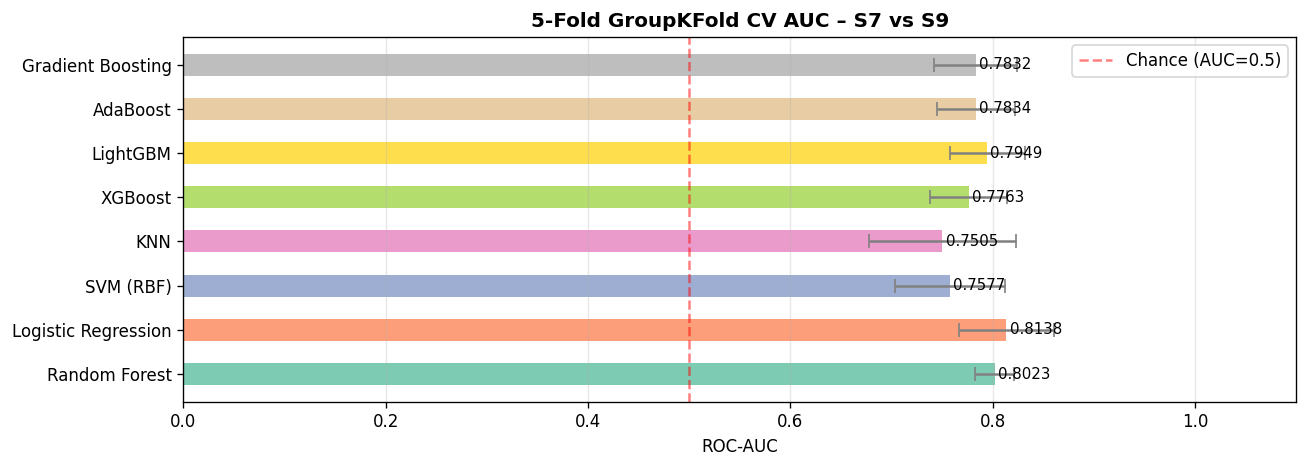

In [18]:
# ── FIG 1 – CV AUC Comparison ─────────────────────────────────────────────────
cv_names = list(cv_results.keys())
cv_means = [cv_results[n].mean() for n in cv_names]
cv_stds  = [cv_results[n].std()  for n in cv_names]
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(cv_names, cv_means, xerr=cv_stds, height=0.5,
               color=plt.cm.Set2(np.linspace(0,1,len(cv_names))),
               alpha=0.85, error_kw=dict(ecolor='gray', capsize=4))
for bar, v in zip(bars, cv_means):
    ax.text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Chance (AUC=0.5)')
ax.set_xlabel('ROC-AUC'); ax.set_xlim(0, 1.1)
ax.set_title(f'{N_SPLITS}-Fold GroupKFold CV AUC – S{SCENARIO_A} vs S{SCENARIO_B}',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_cv_auc.png', bbox_inches='tight')
plt.show()

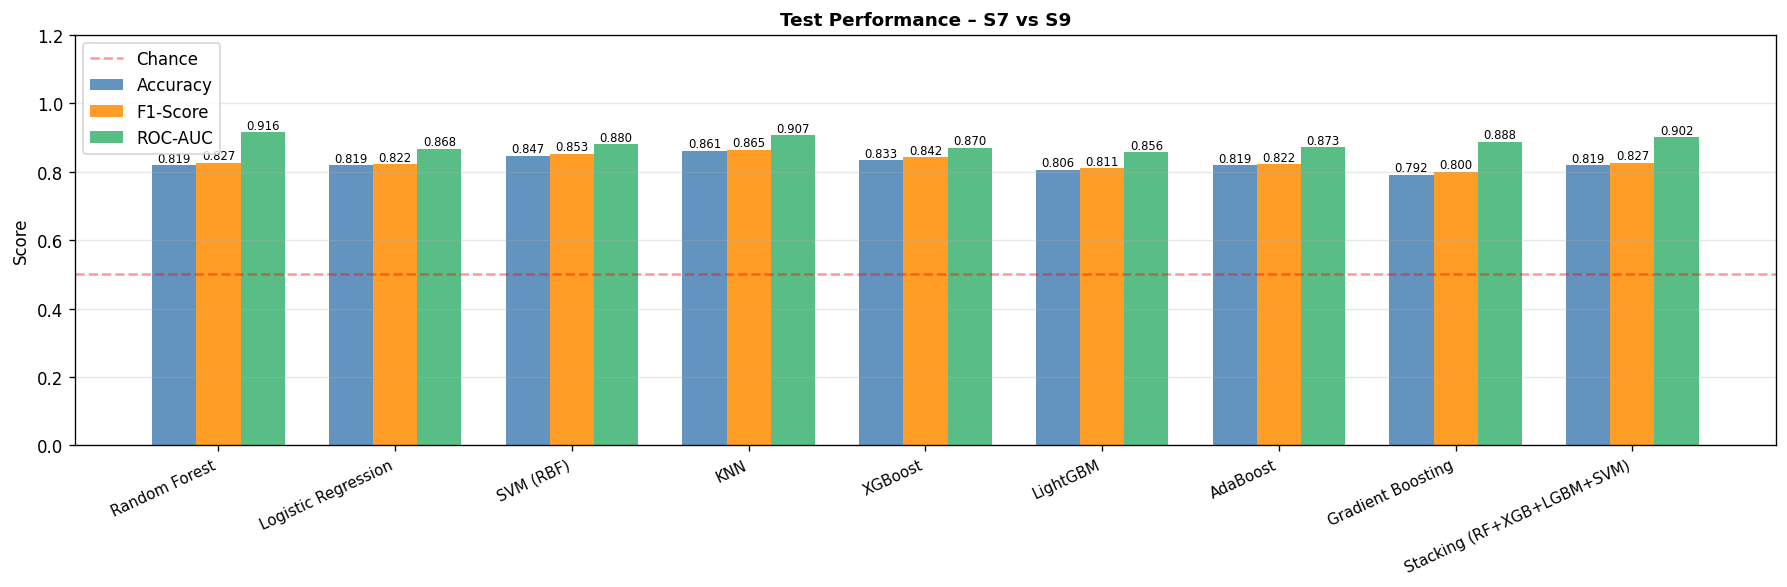

In [19]:
# ── FIG 2 – Test performance (Acc / F1 / AUC) ────────────────────────────────
nt   = list(test_results.keys())
accs = [test_results[n]['accuracy'] for n in nt]
f1s  = [test_results[n]['f1']       for n in nt]
aucs = [test_results[n]['auc']      for n in nt]
x = np.arange(len(nt)); w = 0.25
fig, ax = plt.subplots(figsize=(15, 5))
b1 = ax.bar(x-w, accs, w, label='Accuracy',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x,   f1s,  w, label='F1-Score',  color='darkorange', alpha=0.85)
b3 = ax.bar(x+w, aucs, w, label='ROC-AUC',   color='mediumseagreen', alpha=0.85)
for b in list(b1)+list(b2)+list(b3):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', fontsize=7)
ax.axhline(0.5, color='red', ls='--', alpha=0.4, label='Chance')
ax.set_xticks(x); ax.set_xticklabels(nt, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.2)
ax.set_title(f'Test Performance – S{SCENARIO_A} vs S{SCENARIO_B}',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_test_performance.png', bbox_inches='tight')
plt.show()

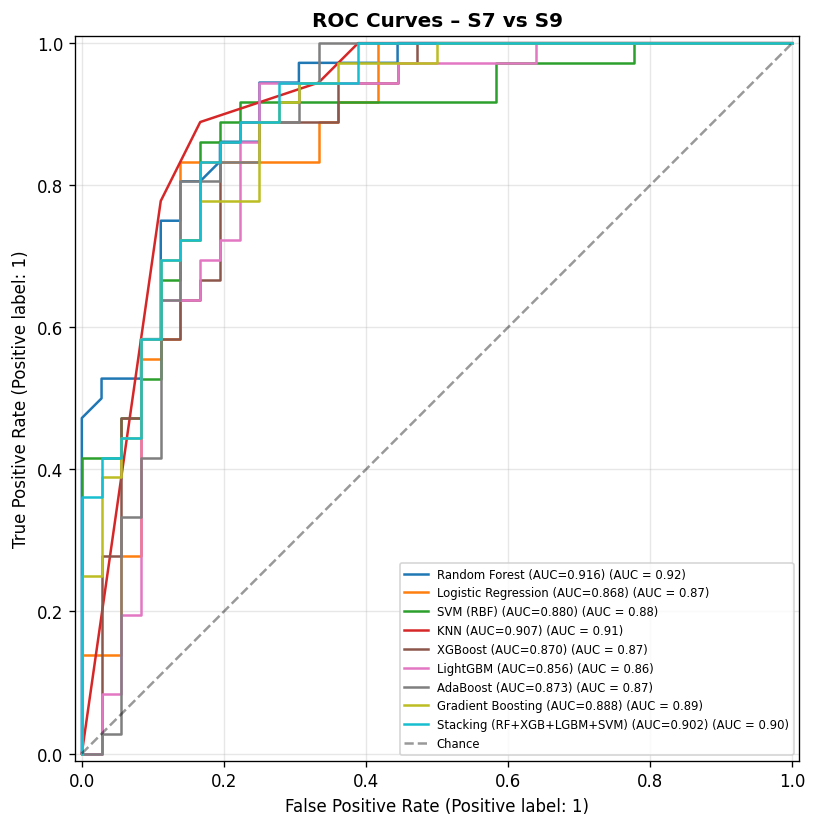

In [20]:
# ── FIG 3 – ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(test_results)))
for (name, res), color in zip(test_results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color, lw=1.5)
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Chance')
ax.set_title(f'ROC Curves – S{SCENARIO_A} vs S{SCENARIO_B}',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_roc_curves.png', bbox_inches='tight')
plt.show()

Best model: Random Forest  AUC=0.9159


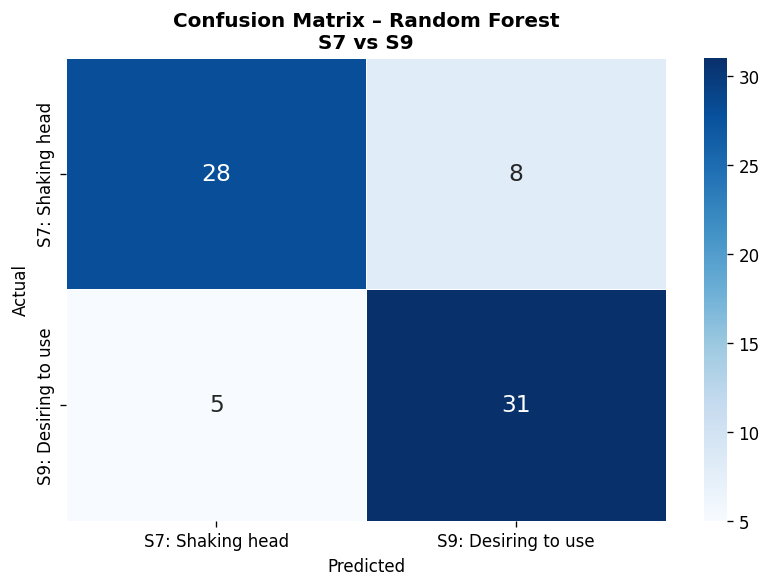

In [21]:
# ── FIG 4 – Best model confusion matrix ──────────────────────────────────────
best_name = max(test_results, key=lambda n: test_results[n]['auc'])
print(f'Best model: {best_name}  AUC={test_results[best_name]["auc"]:.4f}')
cm = confusion_matrix(y_test, test_results[best_name]['y_pred'])
labels_bin = [f'S{SCENARIO_A}: {label_A[:15]}', f'S{SCENARIO_B}: {label_B[:15]}']
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=labels_bin, yticklabels=labels_bin, linewidths=0.5,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix – {best_name}\nS{SCENARIO_A} vs S{SCENARIO_B}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_confusion_matrix_best.png', bbox_inches='tight')
plt.show()

In [22]:
# ── FIG 5 – Classification report ────────────────────────────────────────────
print(classification_report(y_test, test_results[best_name]['y_pred'],
      target_names=labels_bin))

                     precision    recall  f1-score   support

   S7: Shaking head       0.85      0.78      0.81        36
S9: Desiring to use       0.79      0.86      0.83        36

           accuracy                           0.82        72
          macro avg       0.82      0.82      0.82        72
       weighted avg       0.82      0.82      0.82        72



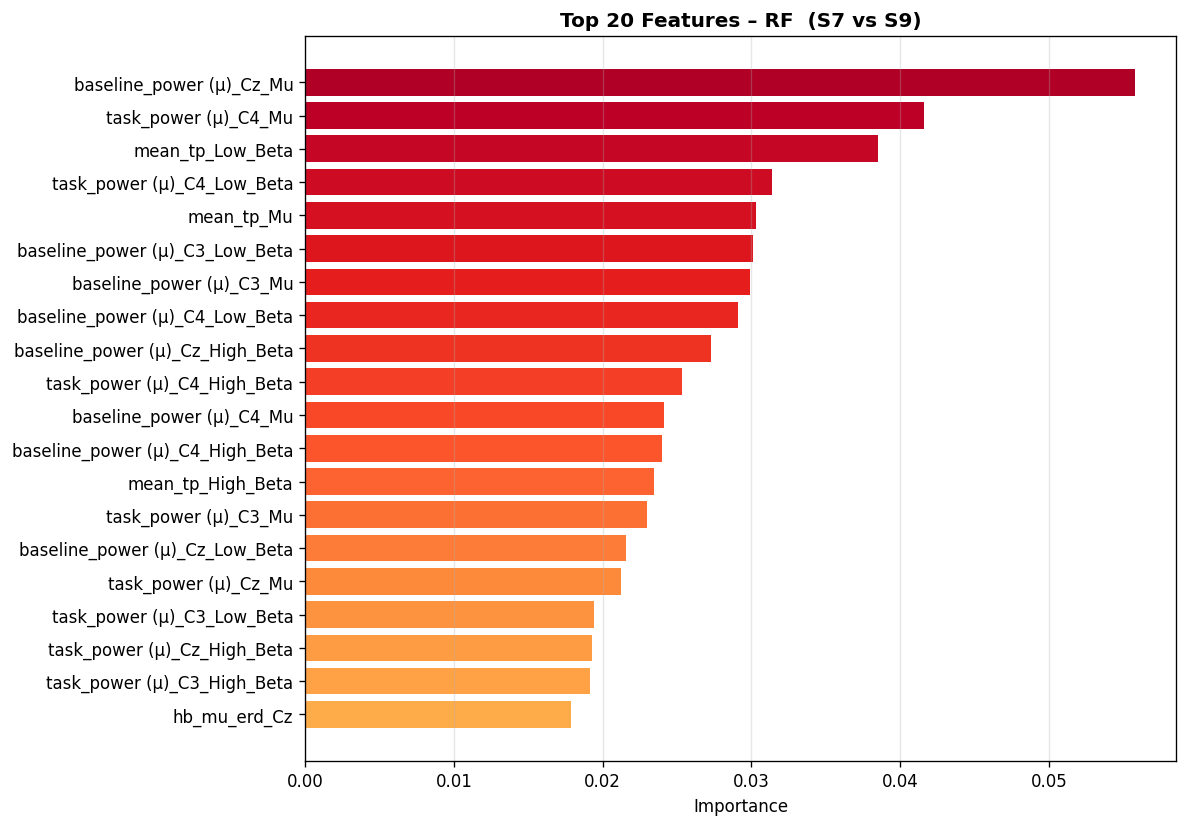

In [23]:
# ── FIG 6 – RF Feature Importance ────────────────────────────────────────────
rf_imp = models['Random Forest'].named_steps['clf'].feature_importances_
top_n = min(20, len(feature_cols))
fi = (pd.DataFrame({'feature': feature_cols, 'importance': rf_imp})
      .sort_values('importance', ascending=False).head(top_n))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi['feature'], fi['importance'],
        color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, top_n))[::-1])
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Features – RF  (S{SCENARIO_A} vs S{SCENARIO_B})',
             fontsize=12, fontweight='bold')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_rf_feature_importance.png', bbox_inches='tight')
plt.show()

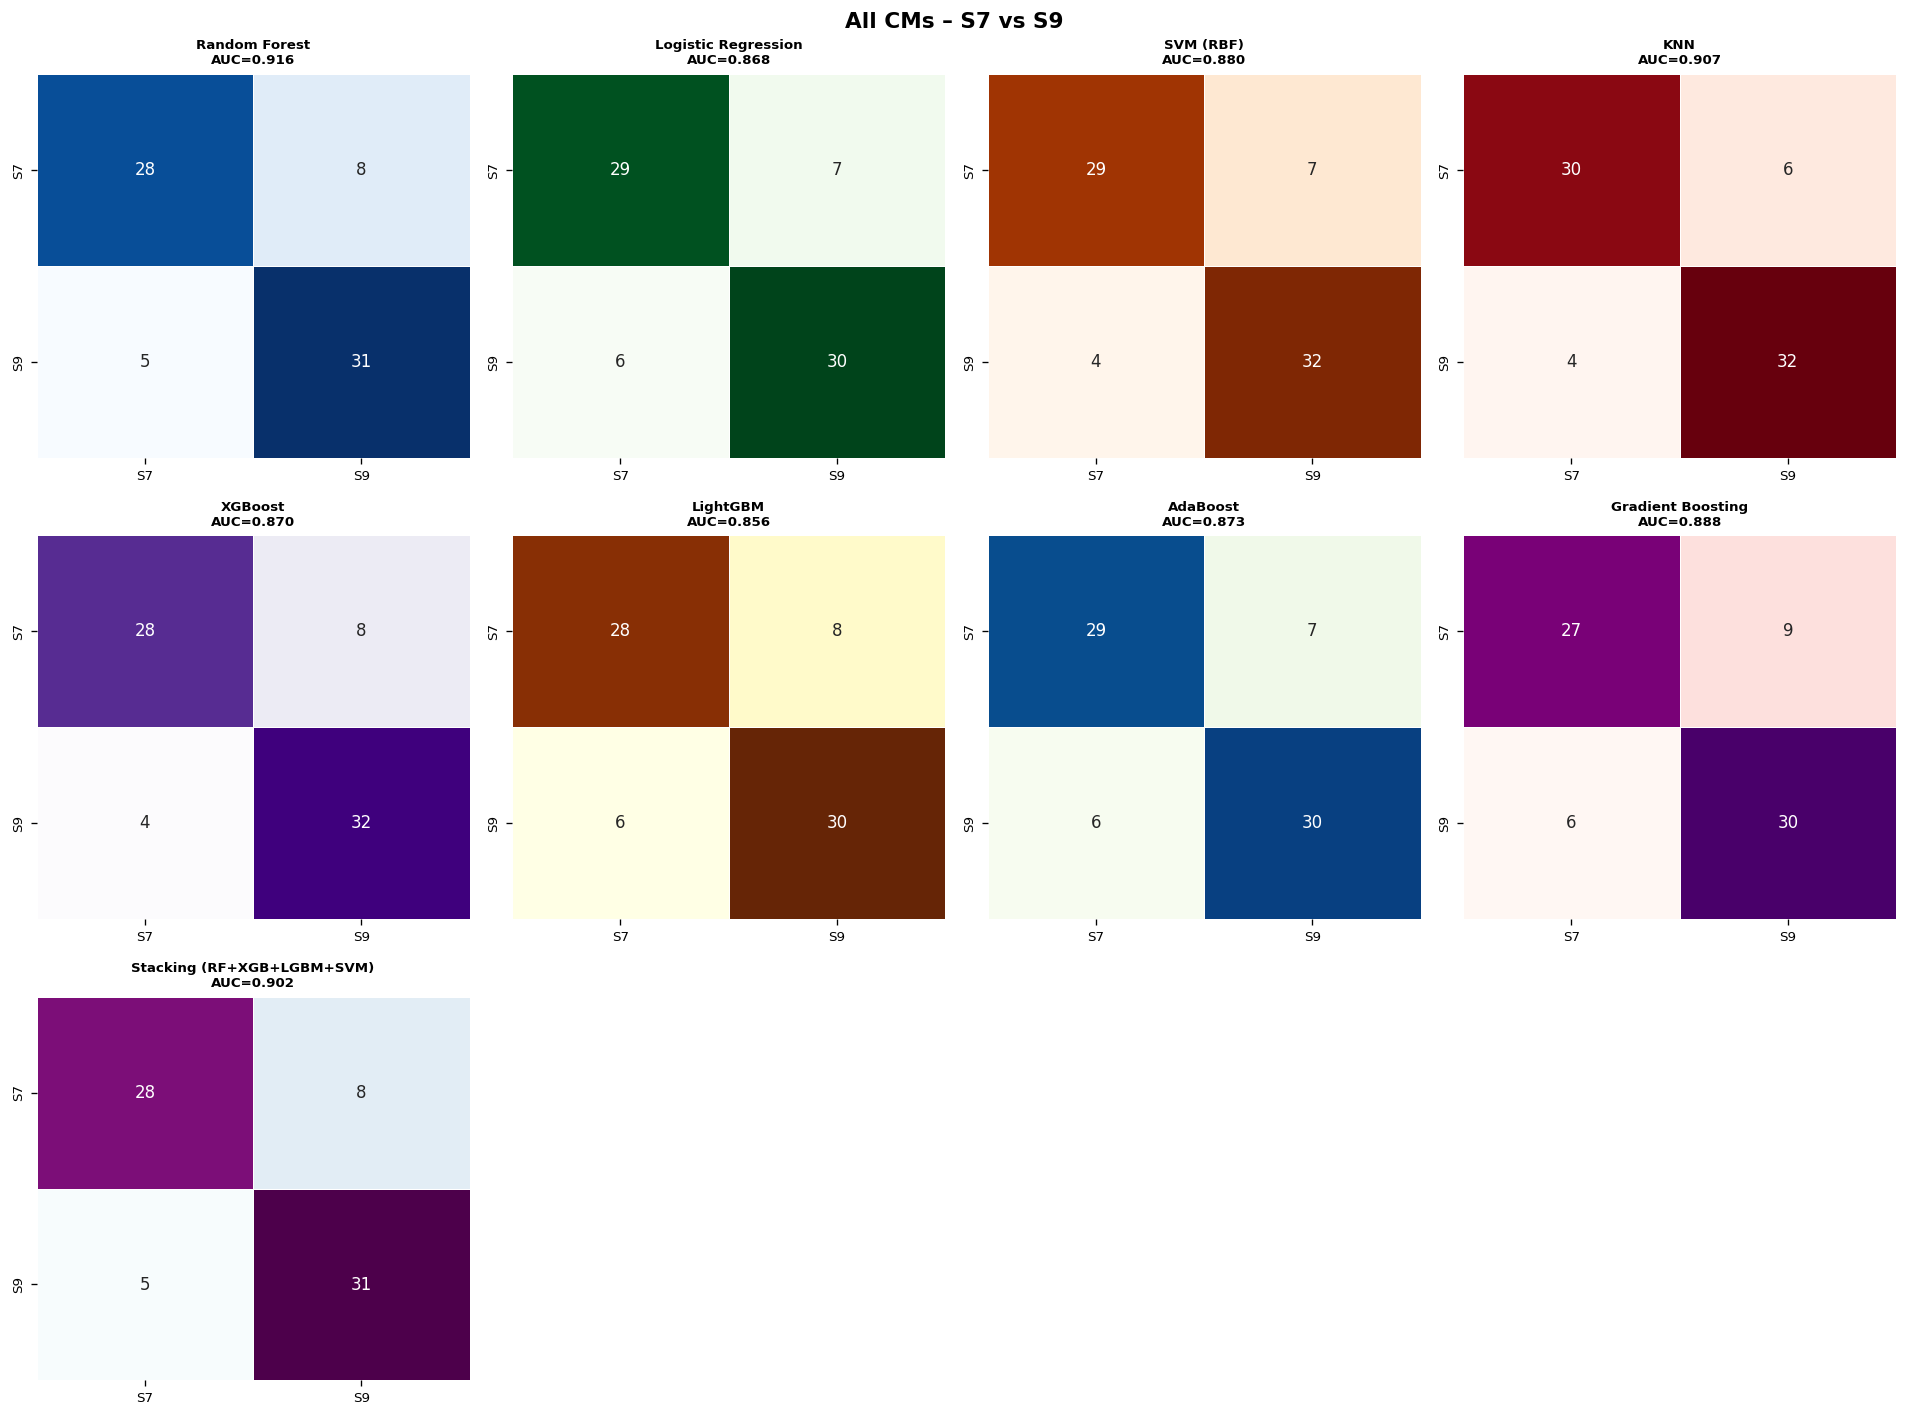

In [24]:
# ── FIG 7 – All confusion matrices grid ──────────────────────────────────────
nm = len(test_results); ncols = 4; nrows = (nm+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
fig.suptitle(f'All CMs – S{SCENARIO_A} vs S{SCENARIO_B}', fontsize=13, fontweight='bold')
cmaps_b = ['Blues','Greens','Oranges','Reds','Purples','YlOrBr','GnBu','RdPu','BuPu']
for idx, (name, res) in enumerate(test_results.items()):
    ax  = axes.flat[idx]
    cmi = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cmi, annot=True, fmt='d', cmap=cmaps_b[idx%len(cmaps_b)],
                ax=ax, xticklabels=[f'S{SCENARIO_A}',f'S{SCENARIO_B}'],
                yticklabels=[f'S{SCENARIO_A}',f'S{SCENARIO_B}'],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{name}\nAUC={res['auc']:.3f}", fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=8)
for idx in range(nm, nrows*ncols): axes.flat[idx].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_all_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Save Results ──────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'Model':        n,
    'Accuracy':     r['accuracy'],
    'F1_Score':     r['f1'],
    'ROC_AUC':      r['auc'],
    'CV_AUC_Mean':  cv_results[n].mean() if n in cv_results else None,
    'CV_AUC_Std':   cv_results[n].std()  if n in cv_results else None,
} for n, r in test_results.items()]).sort_values('ROC_AUC', ascending=False)

out_file = f'{OUTPUT_DIR}/binary_S{SCENARIO_A}_vs_S{SCENARIO_B}_results.csv'
summary.to_csv(out_file, index=False)
print(summary.to_string(index=False))
print(f'\nSaved to {out_file}')

                     Model  Accuracy  F1_Score  ROC_AUC  CV_AUC_Mean  CV_AUC_Std
             Random Forest  0.819444  0.826667 0.915895     0.802296    0.019407
                       KNN  0.861111  0.864865 0.907407     0.750510    0.073082
Stacking (RF+XGB+LGBM+SVM)  0.819444  0.826667 0.902006          NaN         NaN
         Gradient Boosting  0.791667  0.800000 0.888117     0.783163    0.040552
                 SVM (RBF)  0.847222  0.853333 0.880401     0.757653    0.054337
                  AdaBoost  0.819444  0.821918 0.872685     0.783418    0.038784
                   XGBoost  0.833333  0.842105 0.870370     0.776276    0.038100
       Logistic Regression  0.819444  0.821918 0.868056     0.813776    0.046782
                  LightGBM  0.805556  0.810811 0.856481     0.794898    0.037269

Saved to binary_erd_ers_preprocessingModified_S7_vs_S9_outputs/binary_S7_vs_S9_results.csv


In [26]:
df.head()

,filename,category,subject,time,scenario,task,channel,subband,baseline_power (µ),task_power (µ),erd_ers_pct,scenario_num,col_key
54,EEGET-ALS Dataset/ALS01/time1/scenario7/EEG.edf,ALS,ALS01,time1,scenario7,Thinking,Cz,Mu,-0.569295,-0.501963,-1.094647,7,Cz_Mu
55,EEGET-ALS Dataset/ALS01/time1/scenario7/EEG.edf,ALS,ALS01,time1,scenario7,Thinking,Cz,Low_Beta,-0.569117,-0.502032,-1.155468,7,Cz_Low_Beta
56,EEGET-ALS Dataset/ALS01/time1/scenario7/EEG.edf,ALS,ALS01,time1,scenario7,Thinking,Cz,High_Beta,-0.569135,-0.502044,-1.163882,7,Cz_High_Beta
57,EEGET-ALS Dataset/ALS01/time1/scenario7/EEG.edf,ALS,ALS01,time1,scenario7,Thinking,C3,Mu,-0.565813,-0.499114,-0.301088,7,C3_Mu
58,EEGET-ALS Dataset/ALS01/time1/scenario7/EEG.edf,ALS,ALS01,time1,scenario7,Thinking,C3,Low_Beta,-0.567891,-0.500167,-0.272361,7,C3_Low_Beta
